In [10]:
# 05_mortalidade_texto_modelo.ipynb

# 🔧 Setup inicial
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
import joblib
import seaborn as sns



In [11]:
# 📁 Criação de pastas para outputs
os.makedirs("../models", exist_ok=True)
os.makedirs("figures", exist_ok=True)


In [12]:
# 📥 Carrega dados de sumários de alta processados
df_notes = pd.read_csv("../models/discharge_summaries_labeled.csv")
df_notes.head()


,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT,NUM_WORDS
0,175,13702,107527.0,2118-06-14,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2118-6-2**] Discharg...,1943
1,176,13702,167118.0,2119-05-25,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2119-5-4**] D...,1426
2,177,13702,196489.0,2124-08-18,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2124-7-21**] ...,2629
3,180,20646,134727.0,2112-12-10,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2112-12-8**] ...,807
4,184,28063,121936.0,2125-02-16,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2125-2-9**] D...,2117


In [13]:
# 📂 Carregar dados de notas e admissões
notes = pd.read_csv("../data/Mimic-3_patients/NOTEEVENTS/NOTEEVENTS_sorted.csv")
adm = pd.read_csv("../data/Mimic-3_patients/ADMISSIONS/ADMISSIONS_sorted.csv")

# 🧼 Filtrar apenas Discharge Summaries
discharge = notes[notes['CATEGORY'] == 'Discharge summary'].dropna(subset=['TEXT'])
discharge = discharge[['SUBJECT_ID', 'HADM_ID', 'TEXT']]

# 🧩 Juntar com desfecho de mortalidade
df = discharge.merge(adm[['SUBJECT_ID', 'HADM_ID', 'HOSPITAL_EXPIRE_FLAG']], on=['SUBJECT_ID', 'HADM_ID'])
df = df.dropna(subset=['TEXT', 'HOSPITAL_EXPIRE_FLAG'])


In [14]:
# ✍️ Vetorização com TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['TEXT'])
y = df['HOSPITAL_EXPIRE_FLAG']


In [15]:
# 🎲 Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [16]:
# 🤖 Treinar modelo de Regressão Logística
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2352
           1       0.98      0.68      0.80       256

    accuracy                           0.97      2608
   macro avg       0.97      0.84      0.89      2608
weighted avg       0.97      0.97      0.96      2608



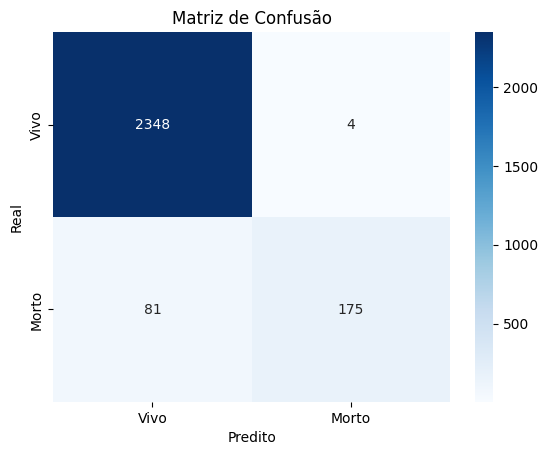

In [17]:
# 📈 Avaliação
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vivo', 'Morto'],
            yticklabels=['Vivo', 'Morto'])

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')

# Criar diretório se não existir
output_path = "../notebooks/figures"
os.makedirs(output_path, exist_ok=True)

# Salvar o gráfico
plt.savefig(os.path.join(output_path, "matriz_confusao_mortalidade.png"), dpi=300, bbox_inches="tight")
plt.show()
